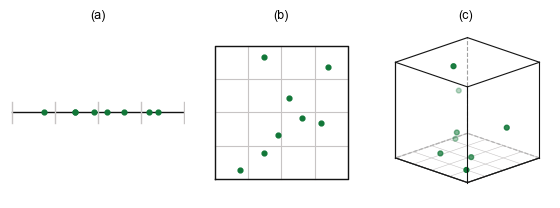

In [ ]:

import numpy as np
import matplotlib.pyplot as plt


ACCENT = "#117738"      # "#2b6cb0" cor dos pontos
GRID = "#c7c4c4"        # cor das linhas de subdivisao
BOX = "#131313"         # cor das bordas do espaco
N_DIV = 4               # subdivisoes por eixo
N_PTS = 8               # numero de pontos

# ----------------------------------------------------------------------
# cada painel usa um subconjunto das coordenadas
# ----------------------------------------------------------------------
rng = np.random.default_rng(22)
pts = rng.uniform(0.00, 1.00, size=(N_PTS, 3))

div_lines = np.linspace(0, 1, N_DIV + 1)  # 0, 0.25, 0.5, 0.75, 1


plt.rcParams.update({"font.family": "Arial", "axes.titlesize": 9, "axes.labelsize": 9})

cm= 1/2.54
fig = plt.figure(figsize=(14*cm, 5*cm), layout= "constrained")

# ----------------------------------------------------------------------
# Painel (a): 1 dimensao
# ----------------------------------------------------------------------
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_title("(a)")

# linha e separadores
ax1.plot([0, 1], [0, 0], color=BOX, lw=1.0, zorder=1)
for x in div_lines:
    ax1.plot([x, x], [-0.06, 0.06], color=GRID, lw=1.0, zorder=1)


ax1.scatter(pts[:, 0], np.zeros(N_PTS), s=12, color=ACCENT, zorder=3)


ax1.set_xlim(-0.01, 1.01)
ax1.set_ylim(-0.5, 0.5)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

# ----------------------------------------------------------------------
# Painel (b): 2 dimensoes
# ----------------------------------------------------------------------
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_title("(b)")

# grade
for g in div_lines:
    ax2.plot([0, 1], [g, g], color=GRID, lw=0.8, zorder=1)
    ax2.plot([g, g], [0, 1], color=GRID, lw=0.8, zorder=1)

# borda do espaço
ax2.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color=BOX, lw=1.0, zorder=2)


ax2.scatter(pts[:, 0], pts[:, 1], s=12, color=ACCENT, zorder=3)


ax2.set_xlim(-0.14, 1.14)
ax2.set_ylim(-0.14, 1.14)
ax2.set_aspect("equal")
ax2.set_xticks([])
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

# ----------------------------------------------------------------------
# Painel (c): 3 dimensoes
# ----------------------------------------------------------------------
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.set_proj_type("ortho")

ax3.set_title("(c)")

# arestas do cubo
corners = np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],
                    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]])
edges = [(0, 1), (1, 2), (2, 3), (3, 0),
         (4, 5), (5, 6), (6, 7), (7, 4),
         (0, 4), (1, 5), (2, 6), (3, 7)]

# canto oculto a partir do angulo de visao
ELEV, AZIM = 20, 45
a, e = np.radians(AZIM), np.radians(ELEV)
eye = np.array([np.cos(e) * np.cos(a), np.cos(e) * np.sin(a), np.sin(e)])
depths = (corners - np.array([0.5, 0.5, 0.5])) @ eye
hidden = int(np.argmin(depths))

for i, j in edges:
    back = (i == hidden or j == hidden)
    p1, p2 = corners[i], corners[j]
    ax3.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color=BOX, lw=0.8,
             linestyle="--" if back else "-", alpha=0.4 if back else 1.0, zorder=1 if back else 4)


# subdivisao leve na face inferior (z=0)
for g in div_lines:
    ax3.plot([0, 1], [g, g], [0, 0], color=GRID, lw=0.4, zorder=1)
    ax3.plot([g, g], [0, 1], [0, 0], color=GRID, lw=0.4, zorder=1)


ax3.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=12, color=ACCENT, zorder=3)


ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.set_zlim(0, 1)
ax3.set_box_aspect((1, 1, 1))

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_zticks([])

ax3.view_init(elev=ELEV, azim=AZIM)

# remove paineis de fundo cinza
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False


fig.savefig("figuras/exemplo_dimenssoes.png", dpi=300)